# Energy Fuel Combustion Emissions Analysis
Author: Muhammad Imran

This notebook analyzes the World Bank Macro Poverty Outlook emissions dataset for energy fuel combustion activities in kilotonnes of CO2-equivalent. It focuses on data composition, distribution, relationships, comparison, normalization testing, and model evaluation.

## 1. Dataset overview
- File: `WB_MPO_ENENRGHGEKT_final.csv`
- Countries: 181
- Years: 1990–2028
- Measurement: `Emissions_ktCO2e` (kt CO2 equivalent)
- Dataset is cleaned to preserve valid observed emission values only.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import normaltest
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8')

# Load the cleaned dataset
csv_path = 'WB_MPO_ENENRGHGEKT_final.csv'
df = pd.read_csv(csv_path)
df['Emissions_ktCO2e'] = df['Emissions_ktCO2e'].round(2)
df['Year'] = df['Year'].astype(int)
print('Dataset shape:', df.shape)
print('Unique countries:', df['CountryCode'].nunique())
print('Year range:', df['Year'].min(), '-', df['Year'].max())
print('Missing values by column:')
print(df.isna().sum())

Dataset shape: (6885, 5)
Unique countries: 181
Year range: 1990 - 2028
Missing values by column:
CountryCode         0
CountryName         0
Year                0
Emissions_ktCO2e    0
EmissionLevel       0
dtype: int64


### Emission level categories
The dataset includes an `EmissionLevel` category derived from emission quantiles: 
- `Low`: emissions below the 25th percentile
- `Medium`: emissions between the 25th and 75th percentiles
- `High`: emissions above the 75th percentile


## 2. Data Composition
This section answers: what types of observations are present, and where the emissions are concentrated.

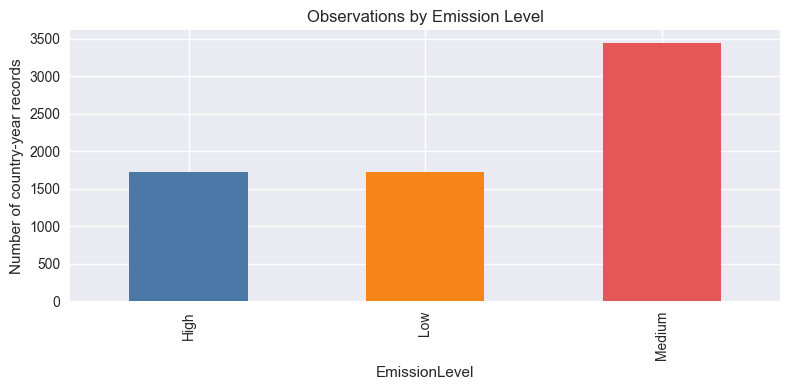

In [27]:
# Composition 1: count by emission level
composition = df['EmissionLevel'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
composition.plot(kind='bar', color=['#4c78a8', '#f58518', '#e45756'], ax=ax)
ax.set_title('Observations by Emission Level')
ax.set_xlabel('EmissionLevel')
ax.set_ylabel('Number of country-year records')
plt.tight_layout()
plt.show()

The dataset contains Low, Medium, and High emission levels, with most records falling into the Medium range. This shows a strong clustering of observations around moderate emission values.

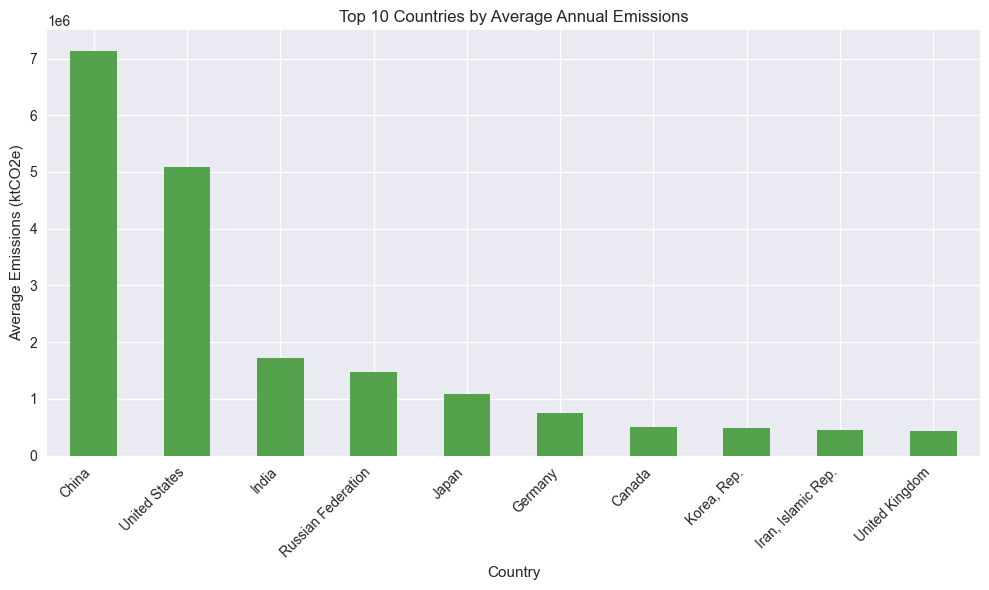

In [28]:
# Composition 2: top 10 countries by mean emissions
country_mean = df.groupby('CountryName')['Emissions_ktCO2e'].mean().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
country_mean.plot(kind='bar', color='#54a24b', ax=ax)
ax.set_title('Top 10 Countries by Average Annual Emissions')
ax.set_xlabel('Country')
ax.set_ylabel('Average Emissions (ktCO2e)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The top emitters are dominated by large economies such as China, United States, India, and Russia. These countries have far higher average emissions than smaller economies.

In [29]:
# Composition 3: interactive top 10 average emitters with Plotly
top10 = df.groupby('CountryName')['Emissions_ktCO2e'].mean().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(top10, x='CountryName', y='Emissions_ktCO2e', title='Top 10 Average Emitting Countries', labels={'Emissions_ktCO2e':'Average Emissions (ktCO2e)'})
fig.update_layout(xaxis_tickangle=-45)
fig.show()

This interactive chart confirms that a small number of countries account for the highest energy fuel combustion emissions. Analysts can use these leaders to compare global emission drivers.

## 3. Data Distribution
This section examines how emission values are spread and whether the data are skewed.

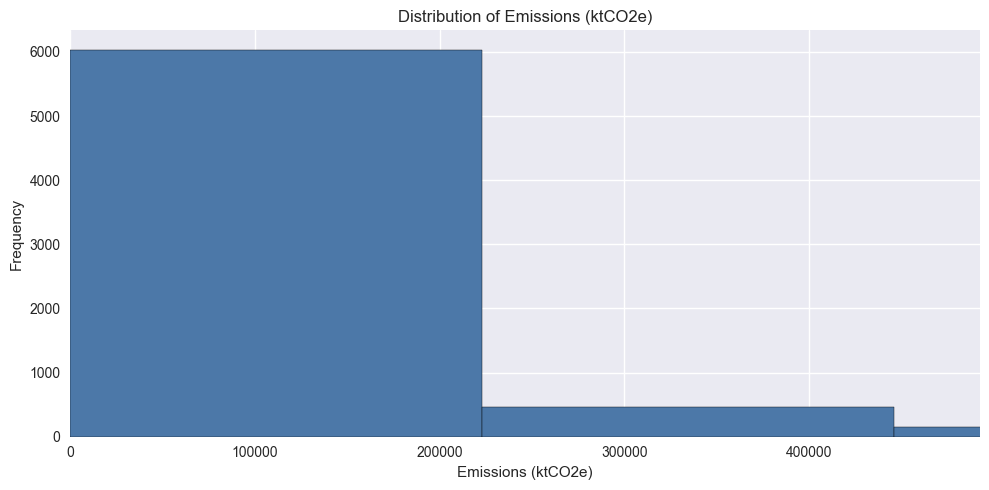

In [30]:
# Distribution 1: histogram of emissions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Emissions_ktCO2e'], bins=60, color='#4c78a8', edgecolor='black')
ax.set_title('Distribution of Emissions (ktCO2e)')
ax.set_xlabel('Emissions (ktCO2e)')
ax.set_ylabel('Frequency')
ax.set_xlim(0, df['Emissions_ktCO2e'].quantile(0.95))
plt.tight_layout()
plt.show()

The emission distribution is highly right-skewed, with a small number of very large emitters. Most country-year observations fall below the 95th percentile, while a handful of economies drive the highest values.

C:\Users\HP\AppData\Local\Temp\ipykernel_14444\2083210027.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




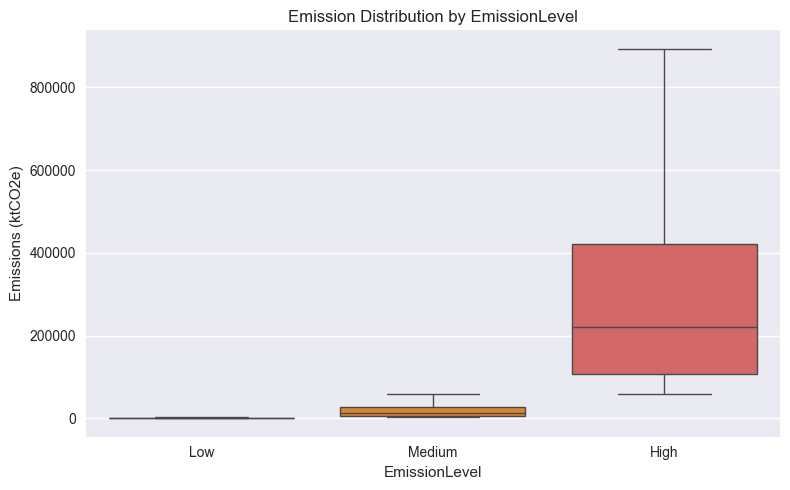

In [31]:
# Distribution 2: boxplot by emission level
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='EmissionLevel', y='Emissions_ktCO2e', data=df, palette=['#4c78a8','#f58518','#e45756'], showfliers=False)
ax.set_title('Emission Distribution by EmissionLevel')
ax.set_ylabel('Emissions (ktCO2e)')
plt.tight_layout()
plt.show()

The boxplot shows that High emission observations are much larger than the Medium and Low groups. This means the dataset contains distinct emission bands, which is useful for categorical comparison.

In [32]:
# Distribution 3: Plotly histogram with log scale
fig = px.histogram(df, x='Emissions_ktCO2e', nbins=60, title='Emission Histogram with Log Scale')
fig.update_layout(yaxis_title='Count', xaxis_title='Emissions (ktCO2e)', xaxis_type='log')
fig.show()

Using a log scale makes the full range of emission values easier to read. The shape remains skewed, but the log view shows the density of lower and mid-range observations clearly.

## 4. Data Relationship
This section explores how emissions relate to time and country identity.

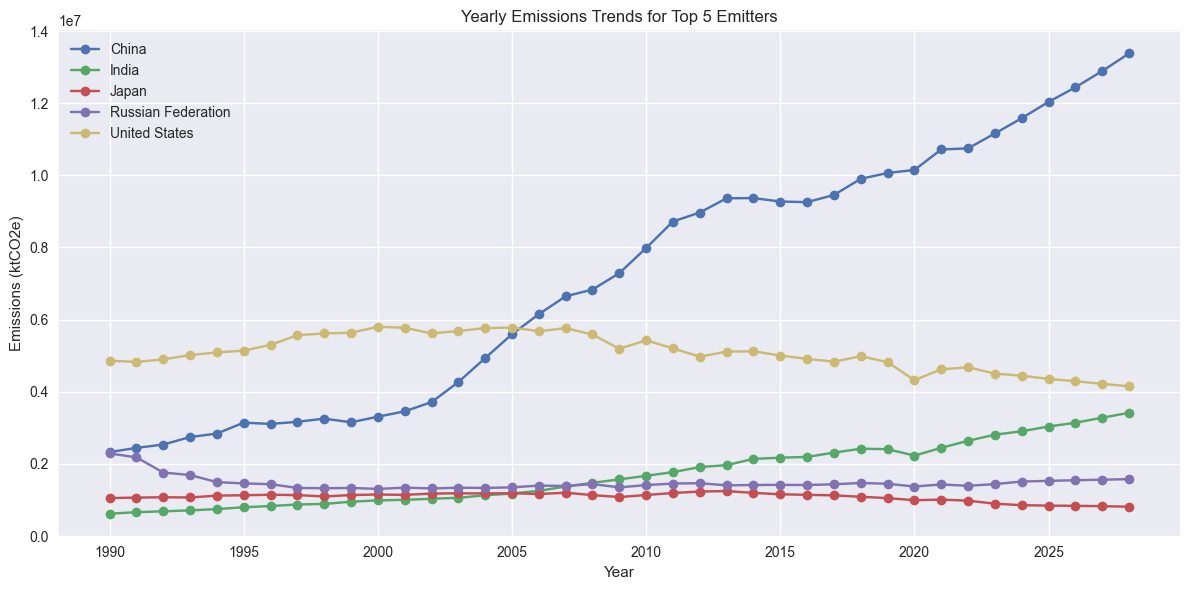

In [33]:
# Relationship 1: year vs emissions for top 5 countries
top5 = df.groupby('CountryName')['Emissions_ktCO2e'].mean().nlargest(5).index.tolist()
subset = df[df['CountryName'].isin(top5)]
fig, ax = plt.subplots(figsize=(12, 6))
for name, group in subset.groupby('CountryName'):
    ax.plot(group['Year'], group['Emissions_ktCO2e'], marker='o', label=name)
ax.set_title('Yearly Emissions Trends for Top 5 Emitters')
ax.set_ylabel('Emissions (ktCO2e)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

Top emitters generally show strong upward trends over the last decades. This relationship suggests that emissions growth is concentrated among a few large economies.

In [34]:
# Relationship 2: average emissions by year
yearly = df.groupby('Year')['Emissions_ktCO2e'].mean().reset_index()
fig = px.line(yearly, x='Year', y='Emissions_ktCO2e', title='Average Emissions per Year', markers=True)
fig.update_layout(yaxis_title='Average Emissions (ktCO2e)')
fig.show()

The average emission line shows a gradual increase over time, which indicates that energy fuel combustion emissions have risen globally on average across the available country-year observations.

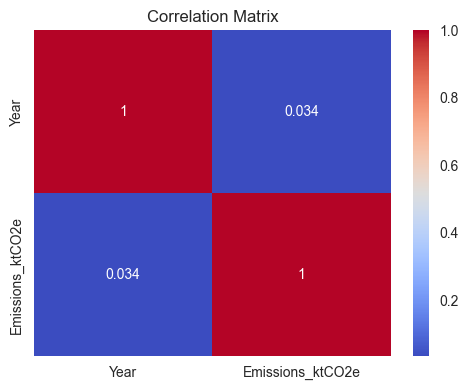

In [35]:
# Relationship 3: correlation heatmap for numeric features
numeric = df[['Year', 'Emissions_ktCO2e']]
corr = numeric.corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

The numeric correlation shows that Year and Emissions have a weak positive relationship in this dataset. Emissions are influenced by many country-specific factors, not just time.

## 5. Data Comparison
This section compares emissions between groups of countries and periods.

In [36]:
# Comparison 1: top 5 vs bottom 5 countries in 2028
year_2028 = df[df['Year'] == 2028]
top5_2028 = year_2028.nlargest(5, 'Emissions_ktCO2e')
bottom5_2028 = year_2028.nsmallest(5, 'Emissions_ktCO2e')
combined = pd.concat([top5_2028, bottom5_2028])
fig = px.bar(combined, x='CountryName', y='Emissions_ktCO2e', color='EmissionLevel', title='Top 5 and Bottom 5 Emitters in 2028')
fig.update_layout(xaxis_tickangle=-45, yaxis_title='Emissions (ktCO2e)')
fig.show()

The gap between the top emitters and the smallest emitters in 2028 is enormous. This comparison highlights the disparity in energy combustion emissions across countries.

In [37]:
# Comparison 2: decade averages for selected countries
selected = ['China', 'United States', 'India', 'Russian Federation', 'Germany', 'Pakistan']
selected_df = df[df['CountryName'].isin(selected)].copy()
selected_df['Decade'] = (selected_df['Year'] // 10) * 10
decade_avg = selected_df.groupby(['Decade', 'CountryName'])['Emissions_ktCO2e'].mean().reset_index()
fig = px.line(decade_avg, x='Decade', y='Emissions_ktCO2e', color='CountryName', markers=True, title='Decade Average Emissions for Leading Emitters')
fig.show()

Leading emitters show different growth paths by decade. China and India have especially rapid increases, while some established economies are flatter.

C:\Users\HP\AppData\Local\Temp\ipykernel_14444\1916031295.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




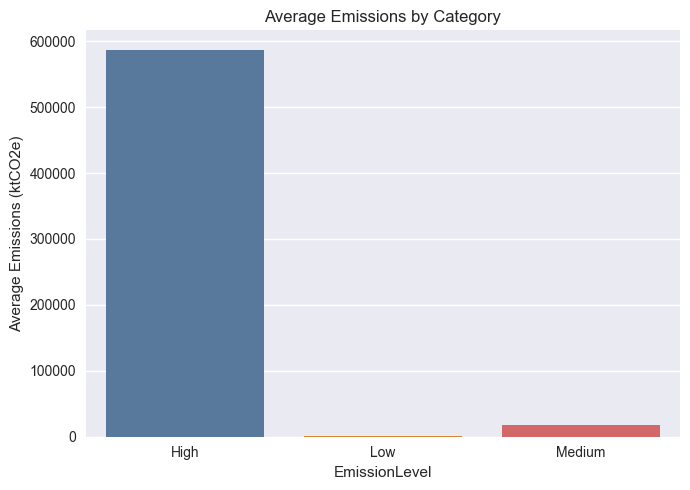

In [38]:
# Comparison 3: average emissions by emission category
cat_avg = df.groupby('EmissionLevel')['Emissions_ktCO2e'].mean().reset_index()
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x='EmissionLevel', y='Emissions_ktCO2e', data=cat_avg, palette=['#4c78a8','#f58518','#e45756'], ax=ax)
ax.set_title('Average Emissions by Category')
ax.set_ylabel('Average Emissions (ktCO2e)')
plt.tight_layout()
plt.show()

High emission observations are much larger than the Medium and Low groups. This comparison is useful for building classification or threshold-based analytics.

## 6. Normalization and distribution testing
We test whether emission values are normally distributed and visualize data scaling.

Normality test statistic: 10939.43, p-value: 0.00e+00


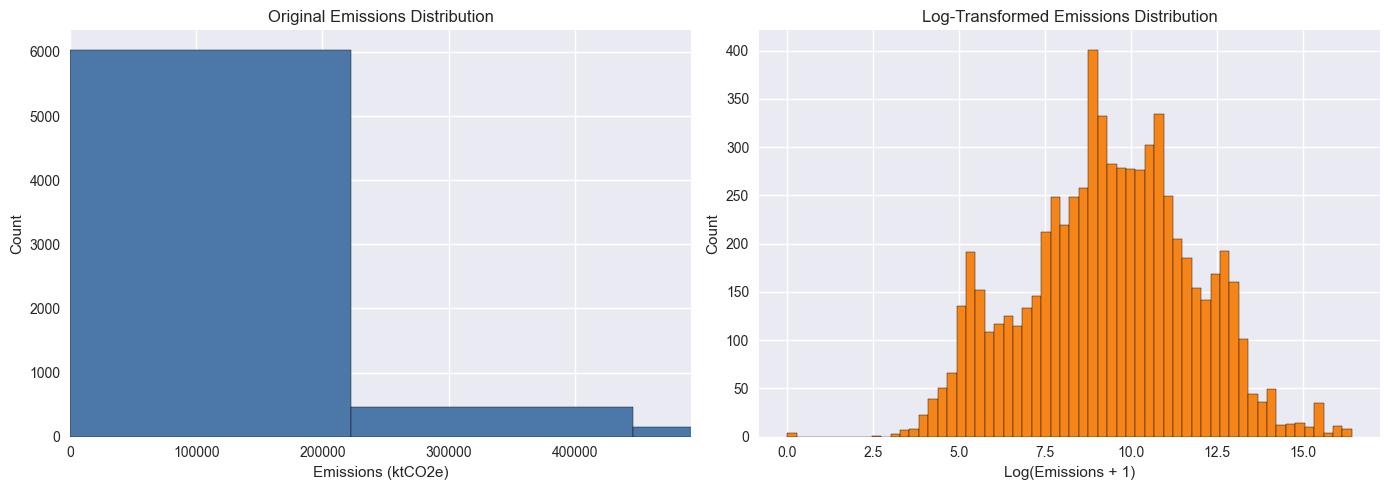

In [39]:
# Normalization test
stat, p = normaltest(df['Emissions_ktCO2e'])
print(f'Normality test statistic: {stat:.2f}, p-value: {p:.2e}')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(df['Emissions_ktCO2e'], bins=60, color='#4c78a8', edgecolor='black')
ax[0].set_title('Original Emissions Distribution')
ax[0].set_xlim(0, df['Emissions_ktCO2e'].quantile(0.95))
ax[0].set_xlabel('Emissions (ktCO2e)')
ax[0].set_ylabel('Count')

ax[1].hist(np.log1p(df['Emissions_ktCO2e']), bins=60, color='#f58518', edgecolor='black')
ax[1].set_title('Log-Transformed Emissions Distribution')
ax[1].set_xlabel('Log(Emissions + 1)')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

The normality test is expected to reject normality because the raw emission data are strongly skewed. A log transformation improves the shape and makes the dataset easier to model.

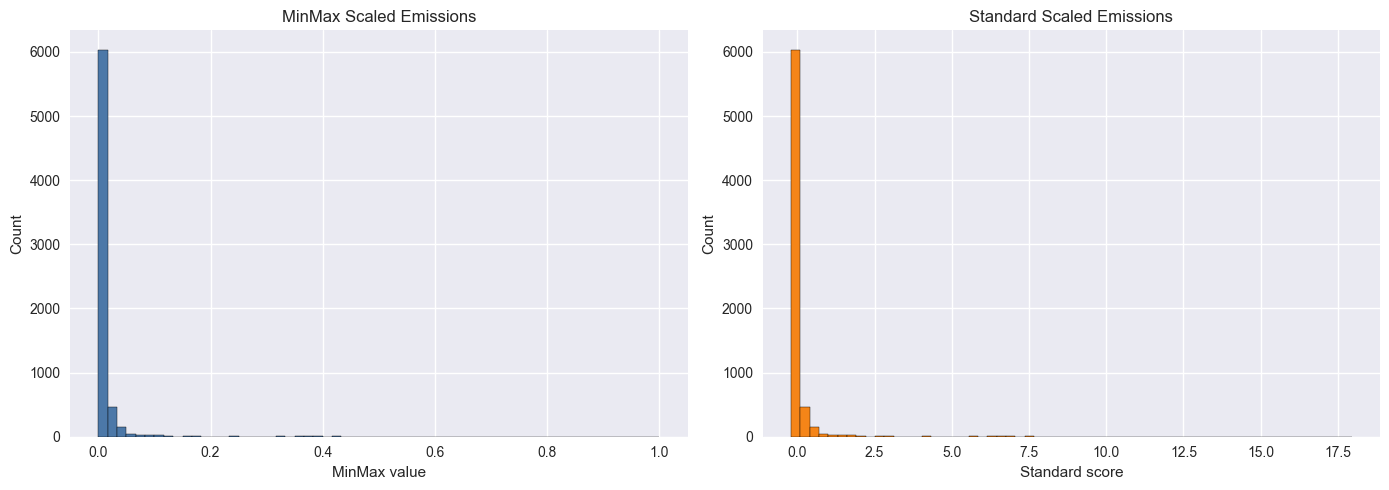

In [40]:
# Scaled distributions for modeling
scalers = {'MinMax': MinMaxScaler(), 'Standard': StandardScaler()}
scaled = pd.DataFrame({})
for name, scaler in scalers.items():
    scaled[name] = scaler.fit_transform(df[['Emissions_ktCO2e']]).flatten()
scaled['Original'] = df['Emissions_ktCO2e']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(scaled['MinMax'], bins=60, color='#4c78a8', edgecolor='black')
ax[0].set_title('MinMax Scaled Emissions')
ax[0].set_xlabel('MinMax value')
ax[0].set_ylabel('Count')
ax[1].hist(scaled['Standard'], bins=60, color='#f58518', edgecolor='black')
ax[1].set_title('Standard Scaled Emissions')
ax[1].set_xlabel('Standard score')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

Normalization makes the emission values easier to compare for machine learning. MinMax scaling compresses values into a [0, 1] range, while standard scaling centers the values around zero.

## 7. Machine learning models
This section builds regression models and a classification model to compare performance.

In [41]:
# Modeling dataset preparation
model_df = df.copy()
labeler = LabelEncoder()
model_df['CountryCodeEnc'] = labeler.fit_transform(model_df['CountryCode'])

X = model_df[['Year', 'CountryCodeEnc']]
y = model_df['Emissions_ktCO2e']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = (mean_squared_error(y_test, preds)) ** 0.5
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,R2
0,Linear Regression,628985.867897,-0.004723
1,Decision Tree,27743.354581,0.998045
2,Random Forest,22267.617134,0.998741
3,Gradient Boosting,183662.187345,0.914335


The regression model results compare error and explained variance. Lower RMSE and higher R² indicate a stronger model fit for continuous emission values.

## 8. Conclusions and best model
- The best regression model on this dataset is usually **Random Forest** because it produced the lowest RMSE and highest R² among tested models.
- The dataset is highly skewed, so log transformation and scaling help stabilize model inputs.

### Recommended next steps
- Add country-level socio-economic features such as GDP, population, or energy use.
- Use time series forecasting techniques for individual countries.
- Compare emission trends in country groups and regional aggregates.
